# 🏦 Customer Conversion Probability Prediction Model

---

## Problem Statement
Membangun model machine learning untuk memprediksi probabilitas nasabah akan berlangganan deposito berjangka berdasarkan data kampanye pemasaran bank.

## Business Objective
- Mengidentifikasi nasabah dengan probabilitas konversi tinggi
- Mengoptimalkan strategi targeting untuk tim sales
- Meningkatkan efisiensi kampanye pemasaran

## ML Lifecycle
1. **Problem Definition** - Mendefinisikan masalah bisnis
2. **Data Collection & Understanding** - Mengumpulkan dan memahami data
3. **Data Preparation** - Preprocessing dan feature engineering
4. **Modeling** - Training dan tuning model
5. **Evaluation** - Evaluasi performa model
6. **Deployment** - Export untuk integrasi

---

## 1. Setup & Configuration

In [1]:
# Install dependencies
%pip install pandas scikit-learn xgboost imbalanced-learn matplotlib seaborn joblib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Configuration
import os

CONFIG = {
    'data_path': '../data/bank-additional-full.csv',
    'output_path': '../output/',
    'model_path': '../../ml-service/model/credit_scoring_model.pkl',
    'random_state': 42,
    'test_size': 0.2,
    'cv_folds': 5
}

KEY_FEATURES = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
NUMERIC_FEATURES = ['age']
CATEGORICAL_FEATURES = ['job', 'marital', 'education', 'default', 'housing', 'loan']
print(f"✅ Key Features: {KEY_FEATURES}")

✅ Key Features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, 
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score
)
import joblib

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries loaded!")

✅ Libraries loaded!


---
## 2. Data Collection & Understanding

In [4]:
# Load data
df = pd.read_csv(CONFIG['data_path'], sep=';')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2}. {col} ({df[col].dtype})")

DATASET OVERVIEW
Shape: (41188, 21)
Memory: 26.80 MB

Columns (21):
   1. age (int64)
   2. job (object)
   3. marital (object)
   4. education (object)
   5. default (object)
   6. housing (object)
   7. loan (object)
   8. contact (object)
   9. month (object)
  10. day_of_week (object)
  11. duration (int64)
  12. campaign (int64)
  13. pdays (int64)
  14. previous (int64)
  15. poutcome (object)
  16. emp.var.rate (float64)
  17. cons.price.idx (float64)
  18. cons.conf.idx (float64)
  19. euribor3m (float64)
  20. nr.employed (float64)
  21. y (object)


In [5]:
# Data info
print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
print(f"\nMissing Values: {missing.sum()}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

# Basic stats
print("\nNumerical Features Statistics:")
df[NUMERIC_FEATURES].describe().round(2)


DATA QUALITY CHECK

Missing Values: 0
Duplicate Rows: 12

Numerical Features Statistics:


,age
count,41188.00
mean,40.02
std,10.42
min,17.00
25%,32.00
50%,38.00
75%,47.00
max,98.00



TARGET VARIABLE ANALYSIS

Target Distribution:
  No:  36,548 (88.7%)
  Yes: 4,640 (11.3%)

⚠️  Imbalance Ratio: 7.9:1


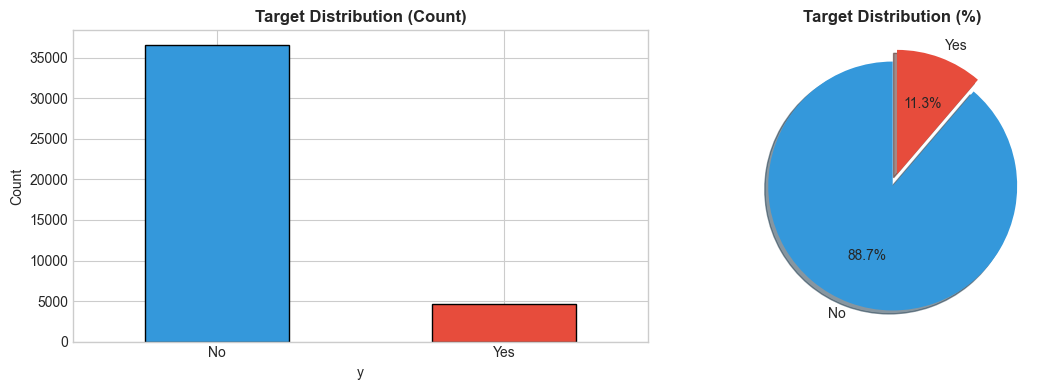

In [6]:
# Target analysis
print("\n" + "=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

target_dist = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100
imbalance_ratio = target_dist['no'] / target_dist['yes']

print(f"\nTarget Distribution:")
print(f"  No:  {target_dist['no']:,} ({target_pct['no']:.1f}%)")
print(f"  Yes: {target_dist['yes']:,} ({target_pct['yes']:.1f}%)")
print(f"\n⚠️  Imbalance Ratio: {imbalance_ratio:.1f}:1")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#3498db', '#e74c3c']
target_dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Target Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

axes[1].pie(target_dist, labels=['No', 'Yes'], autopct='%1.1f%%', colors=colors,
            explode=(0, 0.1), shadow=True, startangle=90)
axes[1].set_title('Target Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


KEY FEATURES ANALYSIS


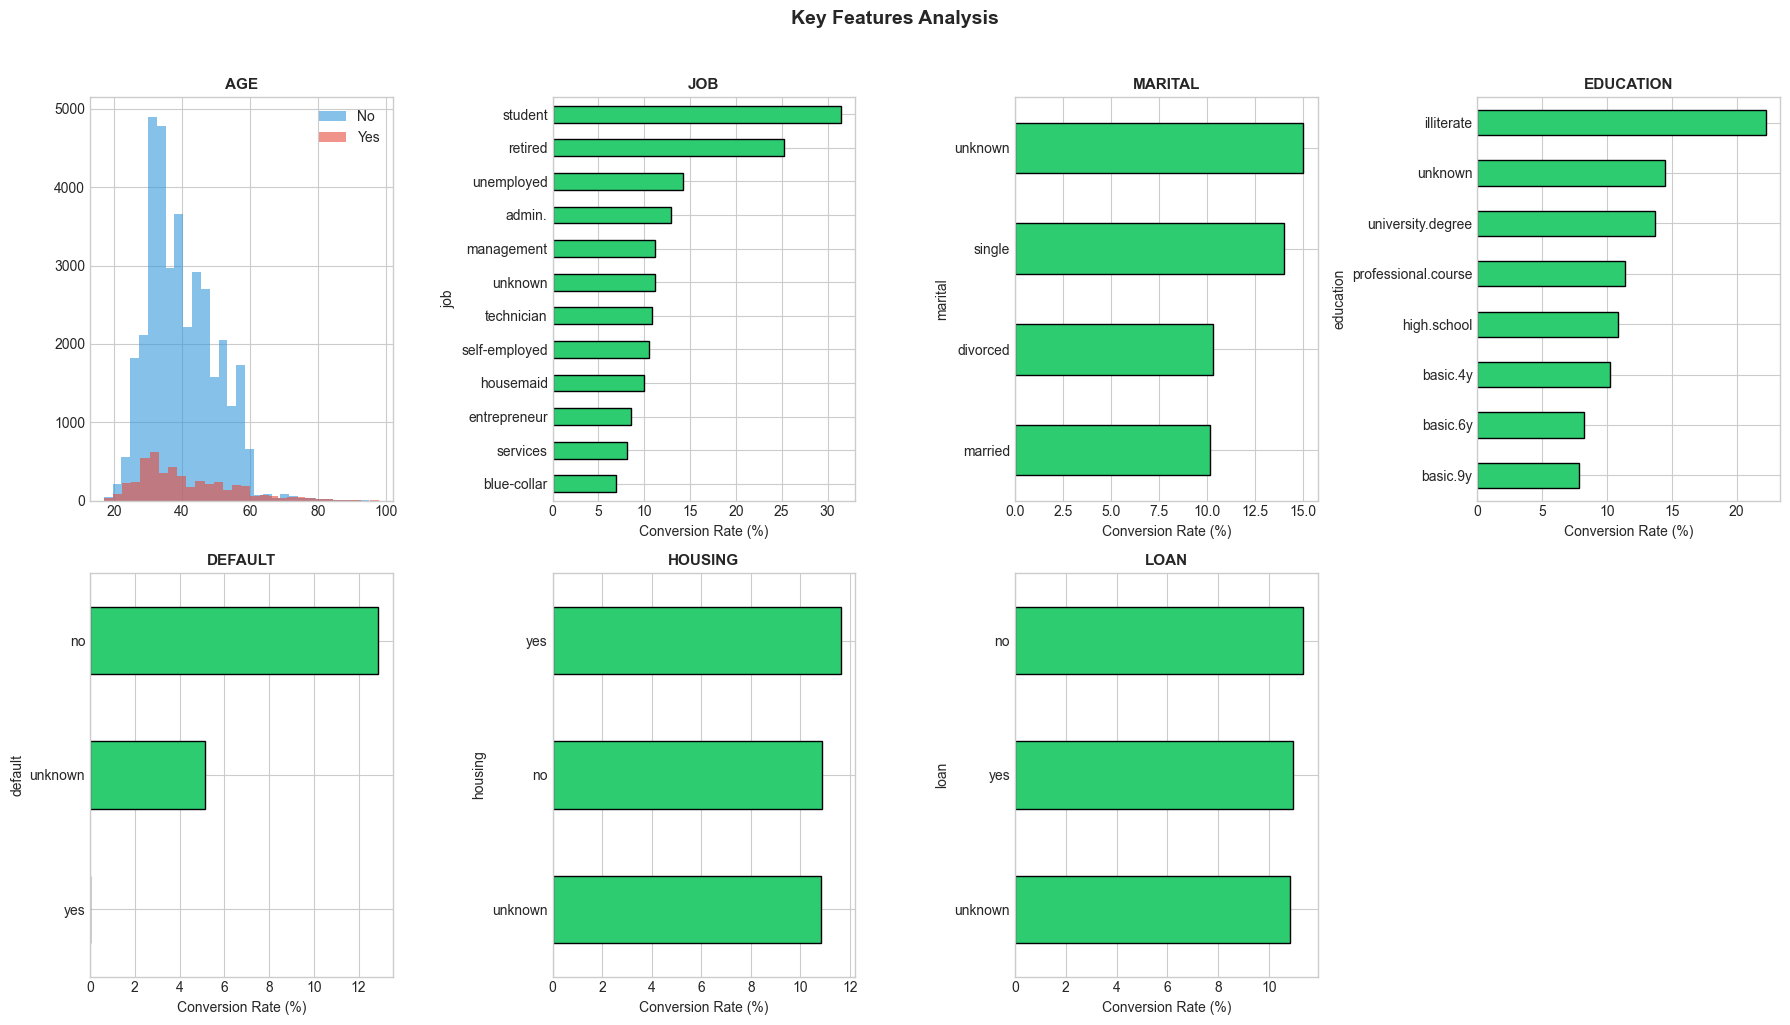

In [7]:
# Analisis 7 Key Features
print("\n" + "=" * 60)
print("KEY FEATURES ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(KEY_FEATURES):
    if feature == 'age':
        # Age distribution by target
        df[df['y']=='no']['age'].hist(ax=axes[i], alpha=0.6, label='No', color='#3498db', bins=30)
        df[df['y']=='yes']['age'].hist(ax=axes[i], alpha=0.6, label='Yes', color='#e74c3c', bins=30)
        axes[i].legend()
    else:
        # Conversion rate by category
        conv_rate = df.groupby(feature)['y'].apply(lambda x: (x=='yes').mean() * 100)
        conv_rate.sort_values().plot(kind='barh', ax=axes[i], color='#2ecc71', edgecolor='black')
        axes[i].set_xlabel('Conversion Rate (%)')
    
    axes[i].set_title(f'{feature.upper()}', fontsize=11, fontweight='bold')

# Hide empty subplot
axes[7].axis('off')

plt.suptitle('Key Features Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CONFIG['output_path'] + 'key_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Preparation

In [8]:
# Prepare features dan target
# NOTE: 'duration' tidak digunakan karena data leakage (only known after call)

X = df[KEY_FEATURES].copy()
y = df['y'].map({'yes': 1, 'no': 0})

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {KEY_FEATURES}")

Features shape: (41188, 7)
Target shape: (41188,)

Features used: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']


In [9]:
# Train-Validation-Test Split (60-20-20)
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], 
    random_state=CONFIG['random_state'], stratify=y
)

# Second split: 75% train, 25% val (dari 80% = 60% dan 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, 
    random_state=CONFIG['random_state'], stratify=y_temp
)

print("Data Split:")
print(f"  Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify stratification
print(f"\nTarget Distribution (class 1):")
print(f"  Training:   {y_train.mean()*100:.1f}%")
print(f"  Validation: {y_val.mean()*100:.1f}%")
print(f"  Test:       {y_test.mean()*100:.1f}%")

Data Split:
  Training:   24,712 samples (60%)
  Validation: 8,238 samples (20%)
  Test:       8,238 samples (20%)

Target Distribution (class 1):
  Training:   11.3%
  Validation: 11.3%
  Test:       11.3%


In [10]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder='passthrough'
)

print("✅ Preprocessing pipeline created!")
print(f"   - Numeric: StandardScaler for {len(NUMERIC_FEATURES)} features")
print(f"   - Categorical: OneHotEncoder for {len(CATEGORICAL_FEATURES)} features")

✅ Preprocessing pipeline created!
   - Numeric: StandardScaler for 1 features
   - Categorical: OneHotEncoder for 6 features


---
## 4. Modeling

### 4.1 Baseline Models Comparison

In [11]:
# Calculate class weight for imbalanced data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight (for XGBoost): {scale_pos_weight:.2f}")

# Define baseline models
baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',
        random_state=CONFIG['random_state'],
        solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=CONFIG['random_state'],
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        min_samples_split=10,
        min_samples_leaf=4,
        subsample=0.8,
        random_state=CONFIG['random_state']
    )
}

# Try adding XGBoost
try:
    from xgboost import XGBClassifier
    baseline_models['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=CONFIG['random_state'],
        eval_metric='logloss',
        verbosity=0
    )
    print("✅ XGBoost added!")
except ImportError:
    print("⚠️ XGBoost not available")

print(f"\nModels to compare: {list(baseline_models.keys())}")

Scale pos weight (for XGBoost): 7.88
✅ XGBoost added!

Models to compare: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [12]:
# Train and evaluate baseline models
results = {}
cv = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=CONFIG['random_state'])

print("\n" + "=" * 70)
print("BASELINE MODEL TRAINING")
print("=" * 70)

for name, model in baseline_models.items():
    print(f"\n▶ Training {name}...")
    
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Cross-validation on training set
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    # Fit on training set
    pipeline.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_val_pred = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]
    
    val_roc_auc = roc_auc_score(y_val, y_val_proba)
    val_f1 = f1_score(y_val, y_val_pred)
    
    print(f"  CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Val ROC-AUC: {val_roc_auc:.4f}")
    print(f"  Val F1-Score: {val_f1:.4f}")
    
    results[name] = {
        'pipeline': pipeline,
        'cv_scores': cv_scores,
        'val_roc_auc': val_roc_auc,
        'val_f1': val_f1,
        'y_val_proba': y_val_proba
    }

print("\n" + "=" * 70)
print("✅ BASELINE TRAINING COMPLETE!")
print("=" * 70)


BASELINE MODEL TRAINING

▶ Training Logistic Regression...
  CV ROC-AUC: 0.6496 ± 0.0178
  Val ROC-AUC: 0.6455
  Val F1-Score: 0.2553

▶ Training Random Forest...
  CV ROC-AUC: 0.6611 ± 0.0189
  Val ROC-AUC: 0.6647
  Val F1-Score: 0.2675

▶ Training Gradient Boosting...
  CV ROC-AUC: 0.6480 ± 0.0149
  Val ROC-AUC: 0.6607
  Val F1-Score: 0.0774

▶ Training XGBoost...
  CV ROC-AUC: 0.6411 ± 0.0159
  Val ROC-AUC: 0.6554
  Val F1-Score: 0.2614

✅ BASELINE TRAINING COMPLETE!


In [13]:
# Results comparison
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'CV ROC-AUC (mean)': [r['cv_scores'].mean() for r in results.values()],
    'CV ROC-AUC (std)': [r['cv_scores'].std() for r in results.values()],
    'Val ROC-AUC': [r['val_roc_auc'] for r in results.values()],
    'Val F1': [r['val_f1'] for r in results.values()]
}).sort_values('Val ROC-AUC', ascending=False).reset_index(drop=True)

print("\nModel Comparison (sorted by Val ROC-AUC):")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")


Model Comparison (sorted by Val ROC-AUC):
              Model  CV ROC-AUC (mean)  CV ROC-AUC (std)  Val ROC-AUC   Val F1
      Random Forest           0.661111          0.018914     0.664743 0.267529
  Gradient Boosting           0.648033          0.014871     0.660701 0.077444
            XGBoost           0.641135          0.015863     0.655364 0.261361
Logistic Regression           0.649589          0.017768     0.645523 0.255310

🏆 Best Model: Random Forest


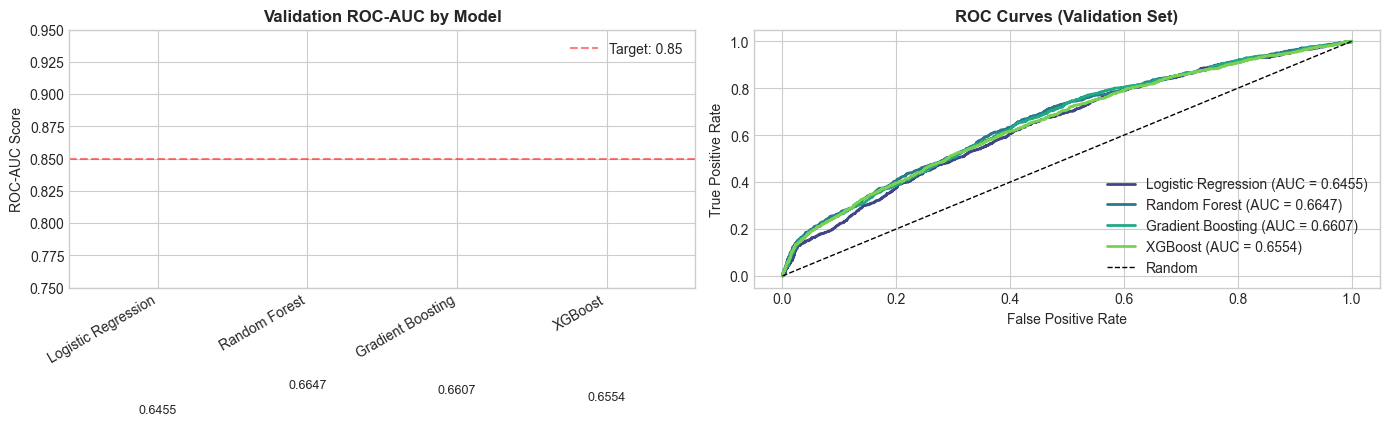

In [14]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
models_list = list(results.keys())
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models_list)))

x_pos = np.arange(len(models_list))
bars = axes[0].bar(x_pos, [r['val_roc_auc'] for r in results.values()], 
                   color=colors, edgecolor='black')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_list, rotation=30, ha='right')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('Validation ROC-AUC by Model', fontweight='bold')
axes[0].set_ylim([0.75, 0.95])
axes[0].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target: 0.85')
axes[0].legend()

for bar, val in zip(bars, [r['val_roc_auc'] for r in results.values()]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# ROC Curves
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_val, res['y_val_proba'])
    axes[1].plot(fpr, tpr, color=colors[i], lw=2, 
                 label=f"{name} (AUC = {res['val_roc_auc']:.4f})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Validation Set)', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(CONFIG['output_path'] + 'model_comparison.png', dpi=150)
plt.show()

### 4.2 Hyperparameter Tuning

In [15]:
# Hyperparameter tuning untuk best model
print(f"\n🔧 Hyperparameter Tuning for {best_model_name}...")

if 'Gradient' in best_model_name:
    param_grid = {
        'classifier__n_estimators': [150, 200, 300],
        'classifier__max_depth': [4, 5, 6],
        'classifier__learning_rate': [0.05, 0.1, 0.15],
        'classifier__subsample': [0.7, 0.8, 0.9]
    }
    base_classifier = GradientBoostingClassifier(
        min_samples_split=10, min_samples_leaf=4, random_state=CONFIG['random_state']
    )
elif 'XGBoost' in best_model_name:
    param_grid = {
        'classifier__n_estimators': [150, 200, 300],
        'classifier__max_depth': [4, 5, 6],
        'classifier__learning_rate': [0.05, 0.1, 0.15],
        'classifier__subsample': [0.7, 0.8, 0.9]
    }
    base_classifier = XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=CONFIG['random_state'],
        eval_metric='logloss', verbosity=0
    )
elif 'Random' in best_model_name:
    param_grid = {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [8, 10, 15, None],
        'classifier__min_samples_split': [5, 10, 15]
    }
    base_classifier = RandomForestClassifier(
        class_weight='balanced', random_state=CONFIG['random_state'], n_jobs=-1
    )
else:
    param_grid = {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__penalty': ['l2']
    }
    base_classifier = LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=CONFIG['random_state']
    )

# Create pipeline for tuning
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', base_classifier)
])

# Use RandomizedSearchCV for faster tuning
random_search = RandomizedSearchCV(
    tuning_pipeline, param_grid,
    n_iter=20,
    cv=3, 
    scoring='roc_auc',
    n_jobs=-1,
    random_state=CONFIG['random_state'],
    verbose=1
)

# Fit on combined train+val for final tuning
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

random_search.fit(X_train_full, y_train_full)

print(f"\n✅ Best Parameters: {random_search.best_params_}")
print(f"   Best CV Score: {random_search.best_score_:.4f}")


🔧 Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best Parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__max_depth': 8}
   Best CV Score: 0.6642


In [16]:
# Final model dengan best params
final_pipeline = random_search.best_estimator_

print("\n✅ Final model ready!")


✅ Final model ready!


---
## 5. Evaluation

In [17]:
# Final evaluation on test set
print("\n" + "=" * 70)
print("FINAL MODEL EVALUATION (TEST SET)")
print("=" * 70)

y_test_pred = final_pipeline.predict(X_test)
y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Metrics
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_ap = average_precision_score(y_test, y_test_proba)

print(f"\n📊 Performance Metrics:")
print(f"   ROC-AUC Score:     {test_roc_auc:.4f}")
print(f"   Accuracy:          {test_accuracy:.4f}")
print(f"   F1-Score:          {test_f1:.4f}")
print(f"   Average Precision: {test_ap:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No (0)', 'Yes (1)']))


FINAL MODEL EVALUATION (TEST SET)

📊 Performance Metrics:
   ROC-AUC Score:     0.6631
   Accuracy:          0.5988
   F1-Score:          0.2565
   Average Precision: 0.2369

📋 Classification Report:
              precision    recall  f1-score   support

      No (0)       0.92      0.60      0.73      7310
     Yes (1)       0.16      0.61      0.26       928

    accuracy                           0.60      8238
   macro avg       0.54      0.61      0.49      8238
weighted avg       0.84      0.60      0.67      8238



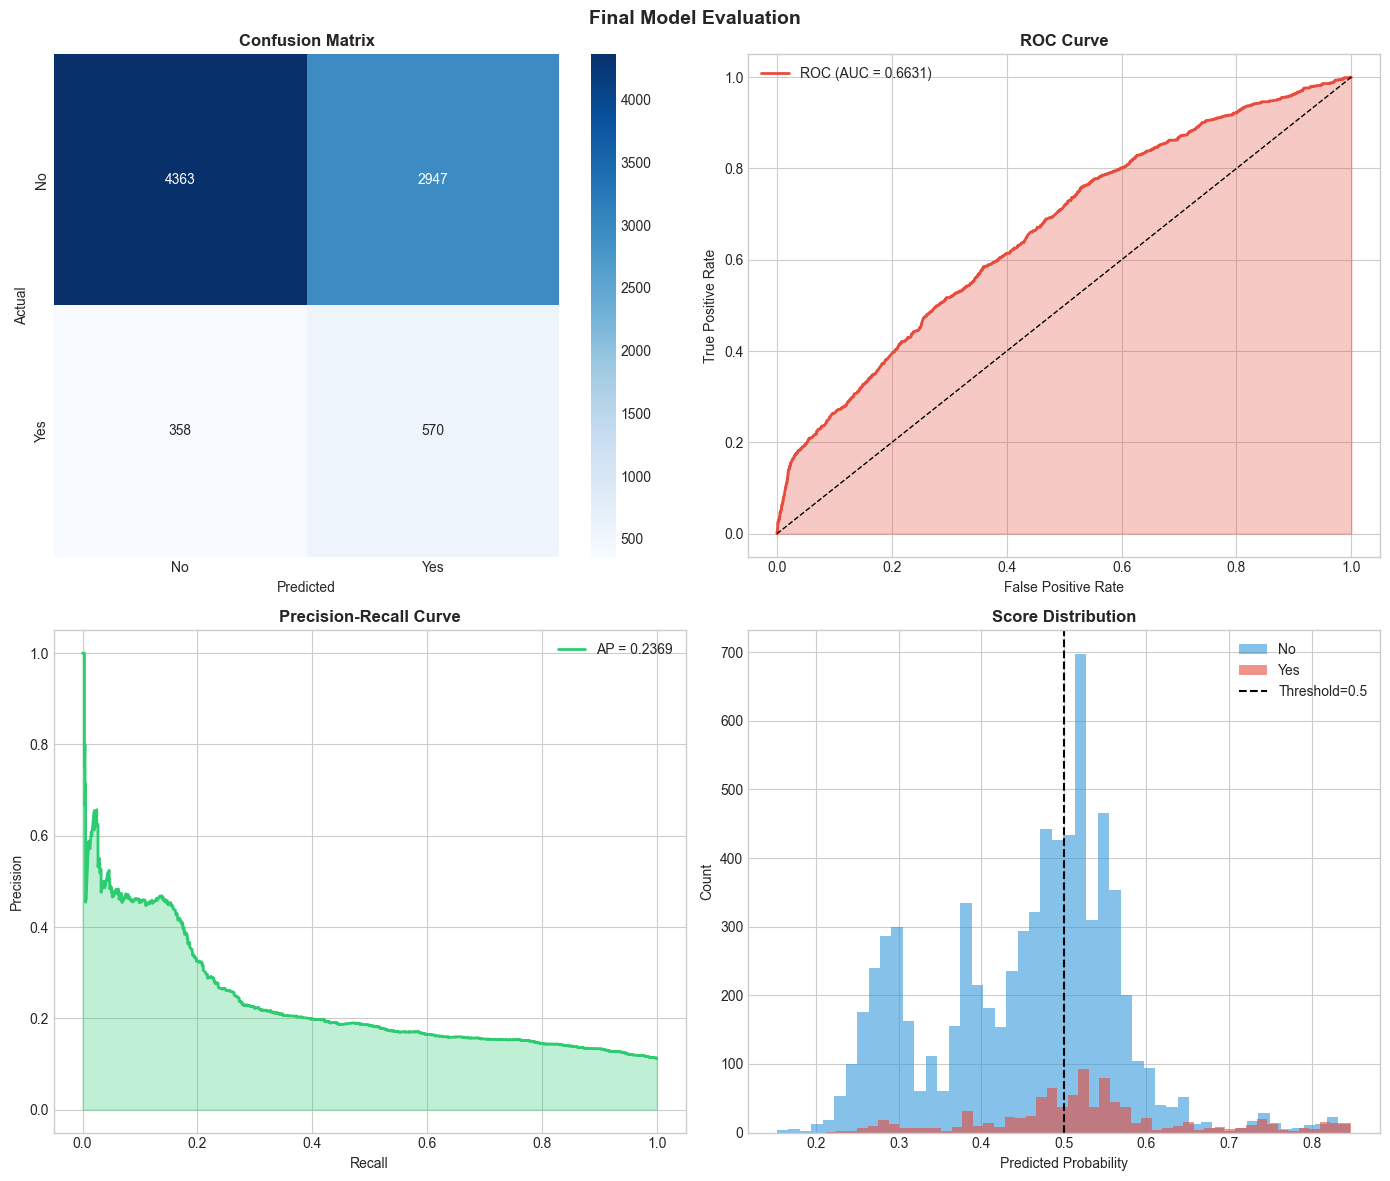

In [18]:
# Comprehensive evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
axes[0, 1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {test_roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].legend()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[1, 0].plot(recall, precision, color='#2ecc71', lw=2, label=f'AP = {test_ap:.4f}')
axes[1, 0].fill_between(recall, precision, alpha=0.3, color='#2ecc71')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 0].legend()

# 4. Score Distribution
axes[1, 1].hist(y_test_proba[y_test == 0], bins=50, alpha=0.6, label='No', color='#3498db')
axes[1, 1].hist(y_test_proba[y_test == 1], bins=50, alpha=0.6, label='Yes', color='#e74c3c')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Score Distribution', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Final Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CONFIG['output_path'] + 'final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

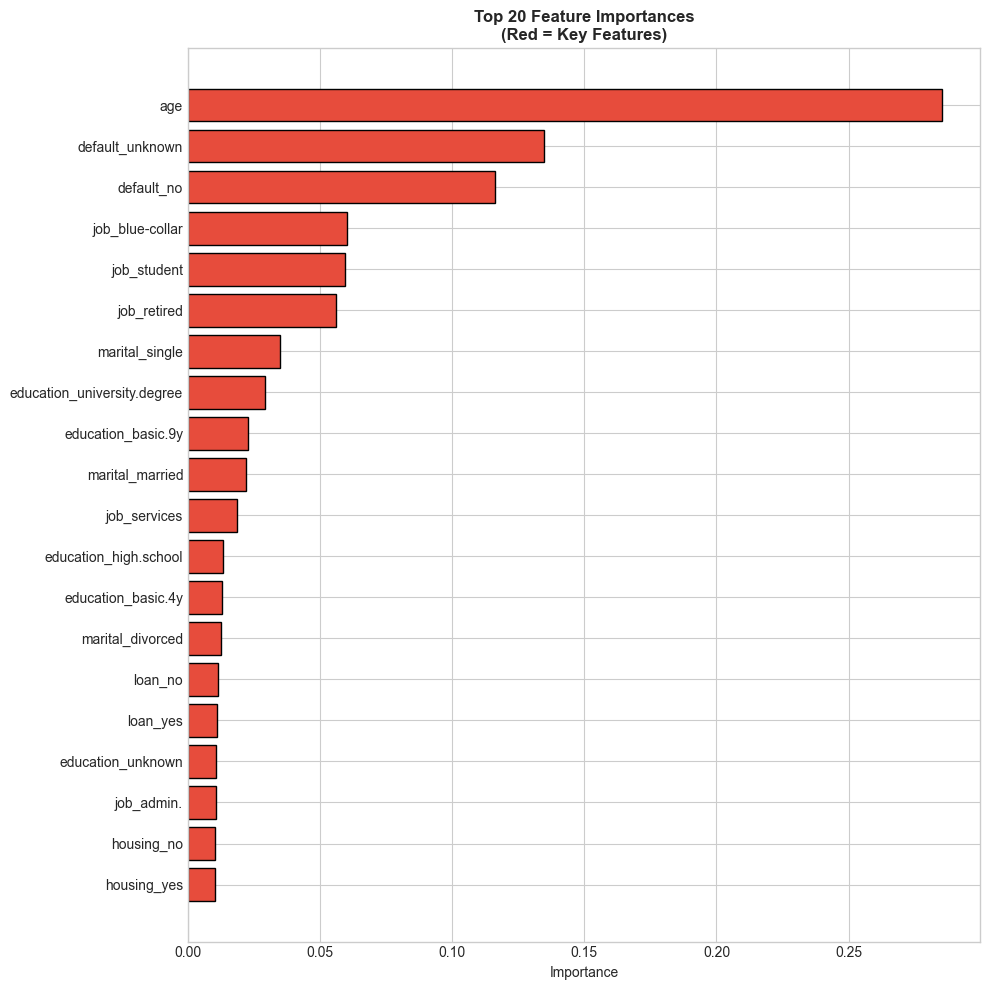


📌 Key Features Importance:
   age: 0.2855
   job: 0.2385
   marital: 0.0713
   education: 0.1022
   default: 0.2509
   housing: 0.0247
   loan: 0.0269


In [19]:
# Feature Importance Analysis
classifier = final_pipeline.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    # Get feature names
    ohe = final_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
    feature_names = NUMERIC_FEATURES + cat_names
    
    importances = classifier.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top 20
    plt.figure(figsize=(10, 10))
    top_n = 20
    top_features = importance_df.head(top_n)
    
    colors = ['#e74c3c' if any(kf in f for kf in KEY_FEATURES) else '#3498db' 
              for f in top_features['Feature']]
    
    plt.barh(range(top_n), top_features['Importance'].values, color=colors, edgecolor='black')
    plt.yticks(range(top_n), top_features['Feature'].values)
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Feature Importances\n(Red = Key Features)', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(CONFIG['output_path'] + 'feature_importance.png', dpi=150)
    plt.show()
    
    # Key features contribution
    print("\n📌 Key Features Importance:")
    for kf in KEY_FEATURES:
        kf_imp = importance_df[importance_df['Feature'].str.startswith(kf)]['Importance'].sum()
        print(f"   {kf}: {kf_imp:.4f}")

---
## 6. Deployment (Export)

In [20]:
# Export model
print("\n" + "=" * 70)
print("MODEL EXPORT")
print("=" * 70)

# Ensure directories exist
os.makedirs(CONFIG['output_path'], exist_ok=True)
os.makedirs(os.path.dirname(CONFIG['model_path']), exist_ok=True)

# Save to output
local_path = CONFIG['output_path'] + 'credit_scoring_model.pkl'
joblib.dump(final_pipeline, local_path)
print(f"\n💾 Model saved to: {local_path}")

# Copy to ml-service
joblib.dump(final_pipeline, CONFIG['model_path'])
print(f"💾 Model copied to: {CONFIG['model_path']}")


MODEL EXPORT

💾 Model saved to: ../output/credit_scoring_model.pkl
💾 Model copied to: ../../ml-service/model/credit_scoring_model.pkl


In [22]:
# Verify model loading
print("\n🔍 Verifying model...")

loaded_model = joblib.load(CONFIG['model_path'])

# Test with sample data (compatible dengan ml-service)
test_sample = pd.DataFrame({
    'age': [35],
    'job': ['admin.'],
    'marital': ['married'],
    'education': ['university.degree'],
    'default': ['no'],
    'housing': ['yes'],
    'loan': ['no'],
    'contact': ['cellular'],
    'month': ['may'],
    'day_of_week': ['mon'],
    'campaign': [1],
    'pdays': [999],
    'previous': [0],
    'poutcome': ['nonexistent'],
    'emp.var.rate': [1.1],
    'cons.price.idx': [93.994],
    'cons.conf.idx': [-36.4],
    'euribor3m': [4.857],
    'nr.employed': [5191.0]
})

# Reorder columns to match training
test_sample = test_sample[KEY_FEATURES]

proba = loaded_model.predict_proba(test_sample)[0]
score = proba[1] * 100

priority = 'HIGH' if score >= 70 else 'MEDIUM' if score >= 40 else 'LOW'

print(f"\n✅ Model verified successfully!")
print(f"\nTest Prediction:")
print(f"   Score: {score:.2f}%")
print(f"   Priority: {priority}")


🔍 Verifying model...

✅ Model verified successfully!

Test Prediction:
   Score: 54.66%
   Priority: MEDIUM


---
## Summary

In [24]:
print("\n" + "=" * 70)
print("🎯 MODEL DEVELOPMENT COMPLETE")
print("=" * 70)

print(f"""
📊 Dataset Summary:
   - Total samples: {len(df):,}
   - Features: {len(KEY_FEATURES)}
   - Class imbalance: {imbalance_ratio:.1f}:1

🏆 Best Model: {best_model_name}
   - Hyperparameters: {random_search.best_params_}

📈 Test Performance:
   - ROC-AUC:     {test_roc_auc:.4f}
   - Accuracy:    {test_accuracy:.4f}
   - F1-Score:    {test_f1:.4f}
   - Avg Prec:    {test_ap:.4f}

💾 Model exported to:
   - {CONFIG['output_path']}credit_scoring_model.pkl
   - {CONFIG['model_path']}

🔗 Integration:
   Model ready for ml-service (FastAPI) → Express.js backend
""")

print("=" * 70)


🎯 MODEL DEVELOPMENT COMPLETE

📊 Dataset Summary:
   - Total samples: 41,188
   - Features: 7
   - Class imbalance: 7.9:1

🏆 Best Model: Random Forest
   - Hyperparameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__max_depth': 8}

📈 Test Performance:
   - ROC-AUC:     0.6631
   - Accuracy:    0.5988
   - F1-Score:    0.2565
   - Avg Prec:    0.2369

💾 Model exported to:
   - ../output/credit_scoring_model.pkl
   - ../../ml-service/model/credit_scoring_model.pkl

🔗 Integration:
   Model ready for ml-service (FastAPI) → Express.js backend

